# Classifying CIFAR-10 with Pretrained CLIP: Original vs Reconstructed Images


- [View Solution Notebook](./solutions.html)
- [View Project Page](https://www.codecademy.com/content-items/3852ed8e56994723932d023c09e24f76)

## Objective

In this project, you'll explore how the **image reconstruction quality** of autoencoders affects the zero-shot classification performance of a pretrained CLIP multimodal model on the CIFAR-10 dataset. 

#### CIFAR-10 Dataset

[CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) is a widely used dataset for computer vision tasks, containing 60,000 color images where each image is:
- **32x32** pixels
- **3** color channels (RGB)
- Labeled into **1 of 10 object classes**

Here's a preview of each of the 10 classes:

<p style="text-align: center;">
  <img src="cifar10_preview.png" width="60%">
</p>

```py
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']
```

Specifically, you will:

**A.** Build and train a convolution-based autoencoder to compress CIFAR-10 images into a low-dimensional latent representation and then reconstruct them to extract meaningful features. 

**B.** Perform zero-shot classification with a pretrained CLIP model to classify both the _original_ and _reconstructed_ images, and compare the side-by-side performance.

Let's get started!

---

### Setup: Import libraries

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from transformers import CLIPProcessor, CLIPModel
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

c:\Users\bmonteir\Documents\Aprendizado\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## Task Group 1: Setup and Loading

#### CIFAR-10 Dataset

[CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) is a widely used dataset for computer vision tasks, containing 60,000 color images where each image is:
- **32x32** pixels
- **3** color channels (RGB)
- Labeled into **1 of 10 object classes**

The 10 classes are: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

### Task 1: Define CIFAR-10 class names

Create a list that contains each of the CIFAR-10 class names.

In [4]:
cifar_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"]

### Task 2: Load the testing set

Load the CIFAR-10 testing set, which contains 10,000 images. Apply a simple preprocessing pipeline that converts each image into a PyTorch tensor.

The CIFAR-10 dataset is located in the following directory: `'/home/ccuser/data'`.

In [7]:
transform = transforms.Compose([
    transforms.ToTensor()
])

test_set = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

print(f"Number of test samples: {len(test_set)}")
print(f"Number of batches: {len(test_loader)}")



Number of test samples: 10000
Number of batches: 313


c:\Users\bmonteir\Documents\Aprendizado\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


### Task 3: Load the first 100 images

Due to memory constraints, create a subset of the first **100 test images** using `Subset()` from `torch.utils.data`. Wrap the subset in a PyTorch `DataLoader` with a batch size of `8` and be sure not to shuffle the test images.

In [10]:
from torch.utils.data import Subset

# 1. Definir os índices que queremos (de 0 a 99)
indices = list(range(100))

# 2. Criar o Subset a partir do test_set que carregamos antes
test_subset = Subset(test_set, indices)

# 3. Criar o DataLoader para o Subset
# Batch size de 8 significa que ele entregará 8 imagens por vez
test_loader_subset = DataLoader(
    test_subset, 
    batch_size=8, 
    shuffle=False
)

# Verificação
print(f"Imagens no subset: {len(test_subset)}")
print(f"Total de batches (100/8): {len(test_loader_subset)}")

Imagens no subset: 100
Total de batches (100/8): 13


### Task 4: Load the pretrained CLIP

Load the pretrained CLIP from Hugging Face under the name `"openai/clip-vit-base-patch32"` while making sure to:
- Move the model to the GPU device.
- Load its corresponding processor.

In [9]:
# 1. Definir o ID do modelo (o "vit-base-patch32" é o equilíbrio ideal entre peso e performance)
model_id = "openai/clip-vit-base-patch32"

# 2. Carregar o Processor (ele faz o redimensionamento e normalização das imagens)
# e o Tokenizer para os textos, tudo em um único objeto.
processor = CLIPProcessor.from_pretrained(model_id)

# 3. Carregar o Modelo e movê-lo para o seu Device (GPU ou CPU)
model = CLIPModel.from_pretrained(model_id).to(device)

print(f"Modelo CLIP carregado com sucesso no dispositivo: {device}")

c:\Users\bmonteir\Documents\Aprendizado\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\bmonteir\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by defau

Modelo CLIP carregado com sucesso no dispositivo: cpu


---
## Task Group 2: Building and Training a Convolutional Autoencoder

### Task 5: Define the CIFARAutoencoder class

Create a convolution-based autoencoder class with an encoder, a decoder, and a forward method.

If using pretrained weights, be sure to construct the architecture exactly in the following order:

1. **Encoder**
    - Add a 2D convolutional layer that:
        - Takes `3` input RGB channels and outputs `8` channels.
        - Uses a `3x3` kernel, `stride=2`, and `padding=1`.
    - Followed by a `ReLU` activation.
    - Finish with a second 2D convolutional layer that:
        - Takes `8` input channels and outputs `16` channels.
        - Also uses a `3x3` kernel, `stride=2`, and `padding=1`.  

2. **Decoder**
    - Add a 2D transposed (reverse) convolutional layer that:
        - Takes `16` input channels and outputs `8` channels.
        - Uses a `3x3` kernel, `stride=2`, `padding=1`, and `output_padding=1`.
    - Followed by a `ReLU` activation.
    - Add a second 2D transposed (reverse) convolutional layer that:
        - Takes `8` input channels and outputs `3` channels (matching the original).
        - Uses a `3x3` kernel, `stride=2`, `padding=1`, and `output_padding=1`.
    - Finish with a `Sigmoid` activation.
      
3. **Forward Method**
    - Pass the input image through the encoder to obtain the latent representation.
    - Pass the latent representation through the decoder to obtain the reconstructed image.
    - Return the reconstructed image.

In [11]:
class CIFARAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # 1. Defina o self.encoder usando nn.Sequential()
        # Coloque as camadas Conv2d e ReLU na ordem pedida.
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1)
        )


        # 2. Defina o self.decoder usando nn.Sequential()
        # Coloque as camadas ConvTranspose2d, ReLU e Sigmoid.
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(16, 8, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(8, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )


    def forward(self, x):
        # 3. Passe o x pelo encoder para gerar o 'latent'
        # 4. Passe o 'latent' pelo decoder para gerar a 'reconstruction'
        # 5. Retorne a reconstrução
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction

### Task 6: Instantiate the autoencoder

Create an instance of the autoencoder class and move it to the appropriate device.

In [12]:
autoencoder = CIFARAutoencoder().to(device)
print(autoencoder)

CIFARAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(16, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(8, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)


### Task 7: Load the pretrained weights (or train the autoencoder on your own)

Load a set of pretrained autoencoder weights saved under `"cifar_autoencoder.pt"`. Use `torch.load()` with `weights_only=True` and `map_location=device`, then load the state dict into your autoencoder.

In [16]:
state_dict = torch.load("cifar_autoencoder.pt", weights_only=True, map_location=device)
autoencoder.load_state_dict(state_dict)


<All keys matched successfully>

<details><summary style="display:list-item; font-size:16px; color:blue;">(Optional) Train the autoencoder</summary>

Optionally, you can train your own autoencoder by running the training loop below. This will train the autoencoder to reconstruct the CIFAR-10 images from scratch. Due to memory limits in the learning environment, we recommend training the autoencoder separately (either offline or in another notebook) and saving the weights for later use:

```py
# Train autoencoder 
torch.manual_seed(42)
epochs = 5
print("Starting training...")
for epoch in range(epochs):
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        recon = conv_autoencoder(x)
        loss = criterion(recon, x)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

print("Training complete!")

# Save trained weights
torch.save(conv_autoencoder.state_dict(), "cifar_autoencoder.pt")
print("Weights saved to cifar_autoencoder.pt")
```
<br>

We've provided a notebook that trains an autoencoder to obtain our pretrained weights. To access the directory containing the notebook, click on the Jupyter icon in the top-left corner of the current notebook.

</details>

### Task 8: Set the autoencoder to evaluation mode

Set the autoencoder to evaluation mode using `.eval()` to disable dropout and batch normalization training behavior.

In [17]:
autoencoder.eval()

CIFARAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(16, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(8, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)

### Task 9: Reconstruct the first 100 images in the testing dataset

Pass the 100 test images (in batches) through the autoencoder to generate reconstructed versions of each image.
- Store the batch of reconstructed images.
- Store the true labels. 

In [20]:
reconstructed_images = []
true_labels = []
print(len(test_loader_subset))

with torch.no_grad():
    for images, labels in test_loader_subset:
        images = images.to(device)
        reconstructions = autoencoder(images)
        reconstructed_images.append(reconstructions.cpu())
        true_labels.append(labels)


13


### Task 10: Concatenate all reconstructed batches

Concatenate all reconstructed batches into a single PyTorch tensor using `torch.cat()` with `dim=0`.

In [21]:
all_reconstructed_images = torch.cat(reconstructed_images, dim=0)
all_true_labels = torch.cat(true_labels, dim=0)

print(f"Shape das imagens reconstruídas: {all_reconstructed_images.shape}")

Shape das imagens reconstruídas: torch.Size([100, 3, 32, 32])


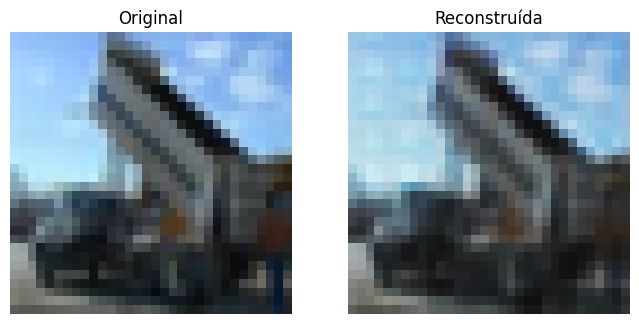

In [27]:
import matplotlib.pyplot as plt

idx = 50

# 2. Pegar a imagem original do subset (ela ainda é um tensor [3, 32, 32])
# Precisamos converter para numpy e mudar a ordem dos eixos para [32, 32, 3]
original_img, _ = test_subset[idx]
original_img = original_img.permute(1, 2, 0).numpy()

# 3. Pegar a imagem reconstruída (que você acabou de gerar)
# Também precisamos do permute para o Matplotlib entender
reconstructed_img = all_reconstructed_images[idx].permute(1, 2, 0).numpy()

# 4. Plotar lado a lado
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_img)
plt.title("Reconstruída")
plt.axis('off')

plt.show()

---
## Task Group 3: CLIP Zero-Shot Classification

### Task 11: Create text descriptions for each CIFAR10 class

Generate a list of text descriptions (one for each CIFAR-10 class) that CLIP will use as zero-shot labels. Format each description as `"a photo of a {class_name}"`.

In [33]:
text_descriptions = []

for cifar in cifar_names:
    if cifar[0] in ['a', 'e', 'i', 'o', 'u']:
        text_descriptions.append(f"an image of an {cifar}.")
    else:
        text_descriptions.append(f"a photo of a {cifar}.")

print(text_descriptions)

['an image of an airplane.', 'an image of an automobile.', 'a photo of a bird.', 'a photo of a cat.', 'a photo of a deer.', 'a photo of a dog.', 'a photo of a frog.', 'a photo of a horse.', 'a photo of a ship.', 'a photo of a truck.']


### Task 12: Define a function to perform zero-shot classification

Create a function that performs zero-shot classification with the CLIP model. The function should take in the reconstructed or original image (as a tensor), the list of text descriptions, the CLIP model, and the CLIP processor:
- Use `transforms.ToPILImage()(image_tensor)` to conver the image tensor `image_tensor` into PIL images that CLIP expects.
- Pass the PIL images through the processor into preprocessed inputs.
- Pass the preprocessed inputs through the CLIP model.
- Obtain the raw outputs, similarity scores, and convert the scores to probabilities.
- The function should return the similarity scores and their probabilities.


In [35]:
from torchvision import transforms

import torch.nn.functional as F

def clip_zero_shot_classify(image_tensor, text_descriptions, model, processor, device=device):
    # Ensure batched input
    if image_tensor.dim() == 3:
        image_tensor = image_tensor.unsqueeze(0)  # [1, C, H, W]

    # Convert each tensor to PIL image
    pil_images = [transforms.ToPILImage()(img.cpu()) for img in image_tensor]

    # Tokenize text + preprocess images
    inputs = processor(
        text=text_descriptions,
        images=pil_images,
        return_tensors="pt",
        padding=True
    ).to(device)

    # CLIP forward pass
    outputs = model(**inputs)

    # logits_per_image shape: [batch_size, num_texts]
    logits_per_image = outputs.logits_per_image

    # convert similarity to probabilities with softmax
    probs = F.softmax(logits_per_image, dim=-1)

    return logits_per_image.detach().cpu(), probs.detach().cpu()

### Task 13: Run zero-shot classification on the reconstructed images

Use the zero-shot classification function to predict labels for each reconstructed CIFAR-10 image.

For each reconstructed image: 
- Compute CLIP's class probabilities.
- Select the class with the highest probability.
- Store the predicted label.

In [37]:
logits, probabilities = clip_zero_shot_classify(
    all_reconstructed_images,
    text_descriptions,
    model,
    processor,
    device
)

print("Logits shape:", logits.shape)
print("Probabilities shape:", probabilities.shape)

Logits shape: torch.Size([100, 10])
Probabilities shape: torch.Size([100, 10])


### Task 14: Run zero-shot classification on the original images

Use the zero-shot classification function to predict labels for each original CIFAR-10 image.

For each original image: 
- Compute CLIP's class probabilities.
- Select the class with the highest probability.
- Store the predicted label.

In [40]:
images_only = [img for img, _ in test_subset]
input_tensor = torch.stack(images_only).to(device)

logits_og, probabilities_og = clip_zero_shot_classify(
    input_tensor,
    text_descriptions,
    model,
    processor,
    device
)

print("Logits shape:", logits_og.shape)
print("Probabilities shape:", probabilities_og.shape)

Logits shape: torch.Size([100, 10])
Probabilities shape: torch.Size([100, 10])


---
## Task Group 4: Comparing Classification Performance

### Task 15: Compare the accuracy between reconstructed and original images

Evaluate CLIP's zero-shot classification performance by computing the *overall* accuracy for both the reconstructed and original images.

Print both accuracy scores.

In [41]:
from sklearn.metrics import accuracy_score

acc_og = accuracy_score(all_true_labels.cpu(), logits_og.argmax(dim=1).cpu())
acc_reconstructed = accuracy_score(all_true_labels.cpu(), logits.argmax(dim=1).cpu())

print(f"Accuracy on original images: {acc_og:.4f}")
print(f"Accuracy on reconstructed images: {acc_reconstructed:.4f}")

Accuracy on original images: 0.8700
Accuracy on reconstructed images: 0.7400


- Is accuracy a meaningful performance metric considering that there are ten CIFAR-10 classes?

### Task 16: Generate classification reports

Create full classification reports for both the reconstructed and original images showing the *per-class* precision, recall, and F1-scores. 

Print both classification reports. 

In [42]:
from sklearn.metrics import classification_report

report_og = classification_report(all_true_labels.cpu(), logits_og.argmax(dim=1).cpu(), target_names=cifar_names)
report_reconstructed = classification_report(all_true_labels.cpu(), logits.argmax(dim=1).cpu(), target_names=cifar_names)

print("Classification Report on Original Images:")
print(report_og)

print("Classification Report on Reconstructed Images:")
print(report_reconstructed)

Classification Report on Original Images:
              precision    recall  f1-score   support

    airplane       0.90      0.90      0.90        10
  automobile       0.67      1.00      0.80         6
        bird       0.88      0.88      0.88         8
         cat       1.00      0.90      0.95        10
        deer       1.00      0.71      0.83         7
         dog       0.55      0.75      0.63         8
        frog       1.00      0.81      0.90        16
       horse       0.92      1.00      0.96        11
        ship       0.93      1.00      0.96        13
       truck       0.89      0.73      0.80        11

    accuracy                           0.87       100
   macro avg       0.87      0.87      0.86       100
weighted avg       0.89      0.87      0.87       100

Classification Report on Reconstructed Images:
              precision    recall  f1-score   support

    airplane       0.89      0.80      0.84        10
  automobile       0.67      0.67      0.67

### Task 17: Compare heatmaps between original and reconstructed images

Visualize the classification reports as heatmaps for the reconstructed and original images:
- Re-compute each classification report as a dictionary using `output_dict=True`. Then, convert the report to a pandas DataFrame and transpose it so that each row corresponds to a CIFAR-10 class with columns for their precision, recall, and F1-score.
- Use seaborn to create heatmaps for each report to compare CLIP's performance on reconstructed versus original images. 

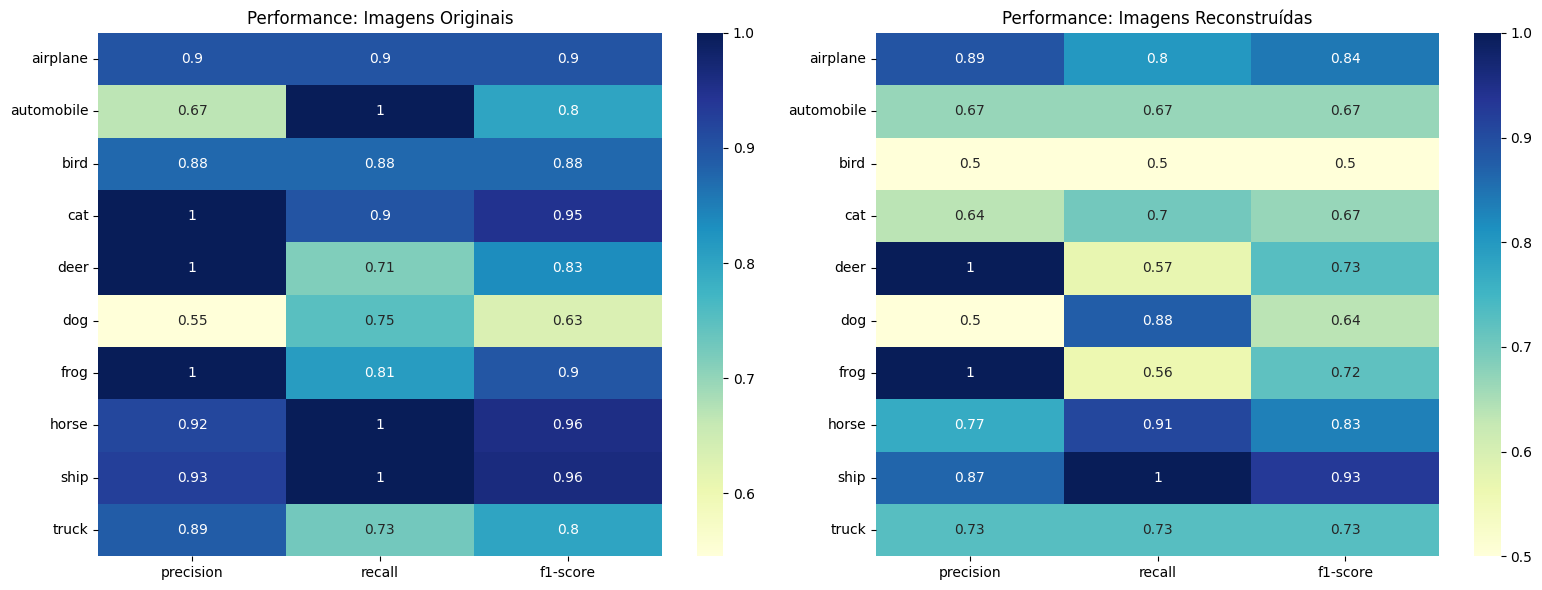

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# 1. Gerar os relatórios (usando argmax para pegar a classe vencedora)
# Certifique-se de que 'logits_og' e 'logits_reconstructed' (seus logits das 100 imagens) estão no mesmo formato
y_true = all_true_labels.cpu()
y_pred_og = logits_og.argmax(dim=1).cpu()
y_pred_rec = logits.argmax(dim=1).cpu() # Ajuste o nome da variável se necessário

dict_report_og = classification_report(y_true, y_pred_og, target_names=cifar_names, output_dict=True)
dict_report_rec = classification_report(y_true, y_pred_rec, target_names=cifar_names, output_dict=True)

# 2. Converter para DataFrame e Transpor
# Filtrando para pegar apenas as primeiras 10 linhas (as classes do CIFAR) e as métricas principais
def clean_report_df(report_dict):
    df = pd.DataFrame(report_dict).transpose()
    # Removemos as linhas de médias para o heatmap focar apenas nas classes
    return df.iloc[:10, :3] # Pega as 10 classes e as colunas precision, recall, f1-score

report_df_og = clean_report_df(dict_report_og)
report_df_rec = clean_report_df(dict_report_rec)

# 3. Criar os Heatmaps Lado a Lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(report_df_og, annot=True, cmap="YlGnBu", ax=ax1)
ax1.set_title("Performance: Imagens Originais")

sns.heatmap(report_df_rec, annot=True, cmap="YlGnBu", ax=ax2)
ax2.set_title("Performance: Imagens Reconstruídas")

plt.tight_layout()
plt.show()

- For the **original images**, which classes does CLIP perform well on? How can you tell from the heatmap?
- For the **reconstructed images**, which classes show noticeably lower precision, recall, or F1-score?

### Task 18: Compute the per-class metric differences (precision, recall, and F1-score)

Create a DataFrame that shows the difference in precision, recall, and F1-scores between original and reconstructed images for each class.

In [46]:
# 1. Calcular a diferença absoluta (Original - Reconstruído)
# Isso mostra quantos pontos percentuais cada métrica caiu
diff_df = report_df_og - report_df_rec

# 2. Renomear as colunas para ficar claro no relatório
diff_df.columns = ['Diff_Precision', 'Diff_Recall', 'Diff_F1-Score']

# 3. Adicionar uma coluna de "Impacto Total" (opcional, mas ajuda na análise)
# A média das quedas nas 3 métricas
diff_df['Mean_Drop'] = diff_df.mean(axis=1)

# 4. Ordenar pelo maior impacto (as classes que mais sofreram)
diff_df_sorted = diff_df.sort_values(by='Mean_Drop', ascending=False)

print("Tabela de Impacto da Reconstrução (Diferença de Métricas):")
print(diff_df_sorted)

Tabela de Impacto da Reconstrução (Diferença de Métricas):
            Diff_Precision  Diff_Recall  Diff_F1-Score  Mean_Drop
bird              0.375000     0.375000       0.375000   0.375000
cat               0.363636     0.200000       0.280702   0.281446
automobile        0.000000     0.333333       0.133333   0.155556
frog              0.000000     0.250000       0.176552   0.142184
horse             0.147436     0.090909       0.123188   0.120511
deer              0.000000     0.142857       0.106061   0.082973
truck             0.161616     0.000000       0.072727   0.078114
airplane          0.011111     0.100000       0.057895   0.056335
ship              0.061905     0.000000       0.034392   0.032099
dog               0.045455    -0.125000      -0.004785  -0.028110


- Which class experienced the most significant drop in performance after reconstruction?
- Are there any classes where performance stays relatively strong even after reconstruction?
- Are there specific metrics (precision, recall, or F1-score) that degrade more noticeably across classes?

### Task 19: Visualize original and reconstructed images

Create a side-by-side visualization comparing the first 10 CIFAR-10 test original images and their reconstructed versions.

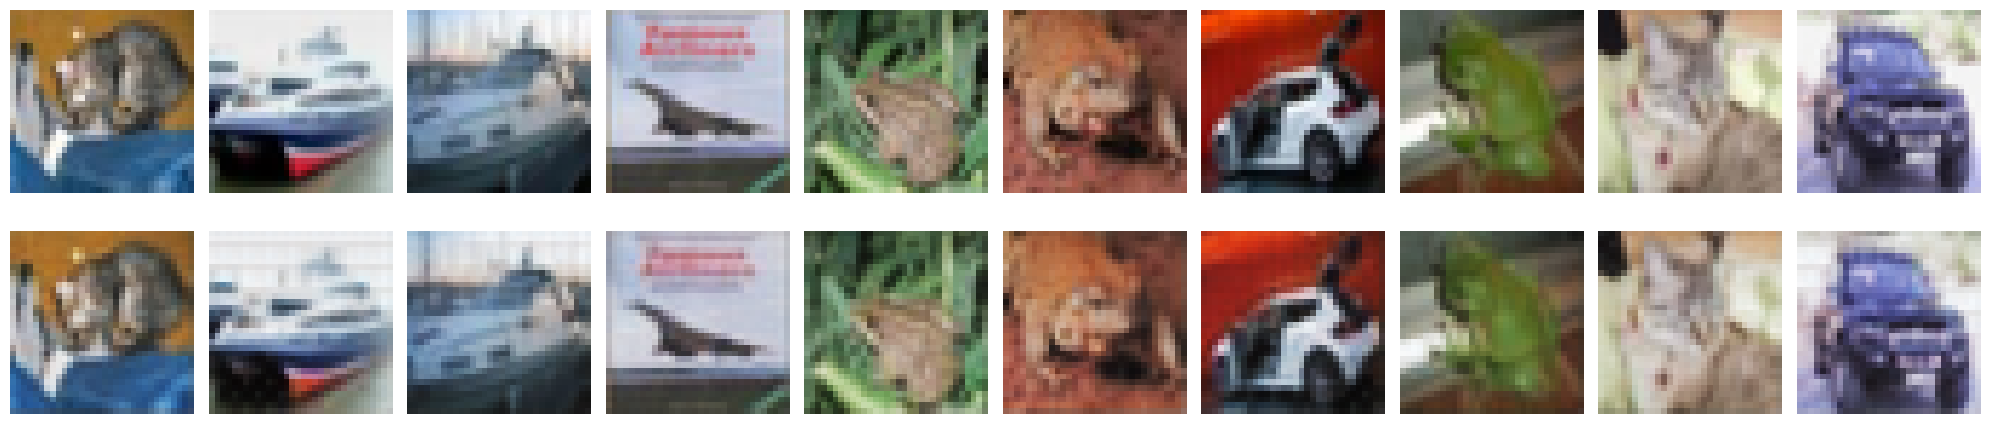

In [47]:
import matplotlib.pyplot as plt

# 1. Configurar a figura: 2 linhas (Original e Reconstruída) e 10 colunas
fig, axes = plt.subplots(2, 10, figsize=(20, 5))

for i in range(10):
    # --- IMAGEM ORIGINAL ---
    # Pegar do subset e ajustar as dimensões para o matplotlib (H, W, C)
    img_og, _ = test_subset[i]
    img_og_plot = img_og.permute(1, 2, 0).numpy()
    
    axes[0, i].imshow(img_og_plot)
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel("Original", fontsize=14, labelpad=20)

    # --- IMAGEM RECONSTRUÍDA ---
    # Pegar do nosso tensor de reconstruções e ajustar dimensões
    img_rec = all_reconstructed_images[i].permute(1, 2, 0).numpy()
    
    axes[1, i].imshow(img_rec)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel("Reconstruída", fontsize=14, labelpad=20)

plt.tight_layout()
plt.show()

How well did the autoencoder preserve key image features?

---
## Conclusion

Congratulations on completing the project. You successfully investigated how the image reconstruction quality of autoencoders affects the zero-shot classification performance of a pretrained CLIP multimodal model on the CIFAR-10 dataset!

In this project, you learned how to:
1. Load and prepare image datasets.
2. Build and train a convolutional autoencoder to compress and reconstruct images.
4. Apply pretrained multimodal models (CLIP) for zero-shot classification.
5. Compare model performance with visualizations.

**Overall accuracy performance drop**
- The pretrained CLIP achieves a 91% accuracy on the original images and only 77% accuracy on the reconstructed images. This 14% differential shows that even a small autoencoder introduces enough visual distortion to reduce CLIP's zero-shot classification performance!

**Per-class observations**
- The classes that showed the most significant drop in performance were automobile, bird, cat, and truck. This suggests that their finer texture and details were not fully preserved by the autoencoder.
- The classes that showed the least significant drop in performance were ship, frog, airplane, and horse. This suggests that their broad shapes or color patterns remain recognizable after reconstruction.


### Takeaways

This experiment highlights a key insight: zero-shot models like CLIP are extremely powerful, but their performance depends heavily on the quality of the input images. Small reconstructions that distort an image can have a measurable impact!

Most importantly, you now have the workflow tools to design and test similar experiments on your own real-world dataset and tasks. Keep going - you're well on your way to building real-world AI projects! 

Happy coding!